**Insurance Fraud Detection**

\Data preprocessing and Cleaning


In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re  
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

In [49]:
# Load raw data
df = pd.read_csv(r'C:\NG\insurance_fraud_detection\data\raw\insurance_claim_fraud_detection_dataset(in).csv')



\creating a copy of raw data for preprocessing


In [50]:
df_clean = df.copy()

In [51]:
df_clean.head()

,claim_id,customer_age,gender,occupation,location_type,customer_tenure_years,policy_type,policy_duration_years,premium_amount,annual_premium,coverage_amount,policy_value,deductible_amount,policy_changes_last_year,claim_amount,repair_estimate,claim_type,incident_severity,incident_location,previous_claims_count,claims_last_12_months,total_claim_amount_previous,claim_frequency_score,police_report_available,witness_available,third_party_involved,incident_hour,weekend_incident,documentation_score,suspicious_activity_score,claim_amount_to_coverage_ratio,premium_to_claim_ratio,policy_start_date,policy_end_date,incident_date,claim_filed_date,claim_settlement_date,claim_submission_delay_days,fraud_investigation_result,claim_rejected,legal_case_filed,settlement_approved,fraud
0,CLM000001,49,Female,Self-employed,Semi-Urban,7.4,Property,3.3,"$22,420",21067,"$486,870",479675,"$11,790",4,"$20,218","$41,020",Medical,Major,Public Place,0.0,1,0,1.83,Yes,Yes,Yes,11,Yes,10.00,4.90,4.15%,110.89%,8/3/2020,2/4/2024,24-May-23,31/05/2023,7/22/2023,7.0,Clear,No,No,Yes,0
1,CLM000002,29,Female,Business,Urban,5.5,auto,3.8,"$15,431",17382,"$721,974",739819,"$12,548",1,"$222,106","$241,421",Medical,Major,Road,1.0,0,62030,2.31,Yes,Yes,No,2,Yes,7.66,5.74,30.76%,6.95%,9/1/2022,1/25/2025,8/13/2024,19-Aug-24,12/19/2024,6.0,Clear,No,No,Yes,0
2,CLM000003,35,male,Salaried,Semi-Urban,1.5,AUTO,7.7,"$18,243",18357,"$892,064",917373,"$24,292",0,"$5,000","$8,655",Accident,Minor,Road,1.0,2,7985,5.20,No,No,No,19,Yes,7.43,2.01,0.56%,364.86%,29-Mar-23,29-11-2024,4-Sep-22,23-Sep-22,10/25/2022,19.0,Clear,No,No,Yes,0
3,CLM000004,24,Female,Business,Urban,7.2,Auto,5.7,"$18,491",18006,"$50,000",156216,"$1,000",3,"$212,674","$239,787",Medical,Minor,Hospital,2.0,1,227104,5.62,no,Yes,No,22,Yes,9.77,5.40,425.35%,8.69%,18/07/2018,8/20/2019,31-12-2022,3/11/2023,5/24/2023,70.0,Clear,No,No,Yes,0
4,CLM000005,41,Male,Salaried,Urban,5.4,Travel,5.3,"$17,354",16708,"$50,000",50271,"$2,717",0,"$73,521","$103,984",Theft,Moderate,Hospital,1.0,0,63514,0.60,No,Yes,Yes,8,No,7.00,6.76,147.04%,23.60%,25-Aug-23,3/24/2027,5/9/2024,11/6/2024,13-12-2024,62.0,Clear,No,No,Yes,0


In [52]:
df.shape

(51000, 43)

\Dropping Data Leakage Columns 

In [53]:
leakage_cols=['fraud_investigation_result','claim_rejected','legal_case_filed','settlement_approved','claim_settlement_date']
df_clean.drop(columns=leakage_cols, axis=1, inplace=True)

In [54]:
df_clean.shape

(51000, 38)

\duplicate records

In [55]:
df_clean.duplicated().sum()

np.int64(1000)

In [56]:
df_clean =df_clean.drop_duplicates()

In [57]:
df_clean.duplicated().sum()

np.int64(0)

\Data cleaning

-- Cleaning currency columns

In [58]:


currency_cols = [
    'premium_amount',
    'coverage_amount', 
    'deductible_amount',
    'claim_amount',
    'repair_estimate'
]

print("BEFORE cleaning:")
print(df_clean[currency_cols].head())
print("\nData types:", df_clean[currency_cols].dtypes.tolist())

BEFORE cleaning:
  premium_amount coverage_amount deductible_amount claim_amount  \
0       $22,420        $486,870           $11,790      $20,218    
1       $15,431        $721,974           $12,548     $222,106    
2       $18,243        $892,064           $24,292       $5,000    
3       $18,491         $50,000            $1,000     $212,674    
4       $17,354         $50,000            $2,717      $73,521    

  repair_estimate  
0        $41,020   
1       $241,421   
2         $8,655   
3       $239,787   
4       $103,984   

Data types: [dtype('O'), dtype('O'), dtype('O'), dtype('O'), dtype('O')]


In [59]:
# Currency cleaning function
def clean_currency(value):
    
    if pd.isnull(value):
        return np.nan
    
    value = str(value)
    cleaned = re.sub(r'[\$,\s"\']', '', value)
    
    try:
        return float(cleaned)
    except ValueError:
        return np.nan  

# Apply to all currency columns
for col in currency_cols:
    df_clean[col] = df_clean[col].apply(clean_currency)

print("AFTER cleaning:")
print(df_clean[currency_cols].head())
print("\nData types:", df_clean[currency_cols].dtypes.tolist())

AFTER cleaning:
   premium_amount  coverage_amount  deductible_amount  claim_amount  \
0         22420.0         486870.0            11790.0       20218.0   
1         15431.0         721974.0            12548.0      222106.0   
2         18243.0         892064.0            24292.0        5000.0   
3         18491.0          50000.0             1000.0      212674.0   
4         17354.0          50000.0             2717.0       73521.0   

   repair_estimate  
0          41020.0  
1         241421.0  
2           8655.0  
3         239787.0  
4         103984.0  

Data types: [dtype('float64'), dtype('float64'), dtype('float64'), dtype('float64'), dtype('float64')]


--cleaning percentage columns

In [60]:
pct_cols = ['claim_amount_to_coverage_ratio', 'premium_to_claim_ratio']

print("BEFORE:")
print(df_clean[pct_cols].head())
print("Data types:", df_clean[pct_cols].dtypes.tolist())

BEFORE:
  claim_amount_to_coverage_ratio premium_to_claim_ratio
0                          4.15%                110.89%
1                         30.76%                  6.95%
2                          0.56%                364.86%
3                        425.35%                  8.69%
4                        147.04%                 23.60%
Data types: [dtype('O'), dtype('O')]


In [62]:
def clean_percentage(value):
    
    if pd.isnull(value):
        return np.nan
    value = str(value).replace('%', '').strip()
    try:
        return float(value) / 100 
    except ValueError:
        return np.nan

for col in pct_cols:
    df_clean[col] = df_clean[col].apply(clean_percentage)

print("\nAFTER:")
print(df_clean[pct_cols].head(3))
print("Data types:", df_clean[pct_cols].dtypes.tolist())


AFTER:
   claim_amount_to_coverage_ratio  premium_to_claim_ratio
0                          0.0415                  1.1089
1                          0.3076                  0.0695
2                          0.0056                  3.6486
Data types: [dtype('float64'), dtype('float64')]


\Standardize Categorical Columns

In [67]:
# Checking categorical columns for inconsistencies
categorical_cols = ['gender', 'occupation', 'location_type', 'policy_type', 
                    'claim_type', 'incident_severity', 'incident_location',
                    'police_report_available', 'witness_available', 
                    'third_party_involved', 'weekend_incident']

for col in categorical_cols:
    print(f"\n{col}: {df_clean[col].unique()[:10]}")  


gender: ['Female' 'male' 'Male' 'FEMALE' 'Other']

occupation: ['Self-employed' 'Business' 'Salaried' 'Retired' 'Student' 'salaried']

location_type: ['Semi-Urban' 'Urban' 'Rural']

policy_type: ['Property' 'auto' 'AUTO' 'Auto' 'Travel' 'Life' 'Health' 'Vehicle']

claim_type: ['Medical' 'Accident' 'Theft' 'Loss' 'Damage' 'Fire']

incident_severity: ['Major' 'Minor' 'Moderate' 'Severe' nan 'MAJOR' 'minor']

incident_location: ['Public Place' 'Road' 'Hospital' 'Home' 'Workplace' 'Other']

police_report_available: ['Yes' 'No' 'no' nan 'N' 'yes' 'Y']

witness_available: ['Yes' 'No' 'yes' 'Y' nan 'no' 'N']

third_party_involved: ['Yes' 'No']

weekend_incident: ['Yes' 'No']


In [ ]:
def standardize_text(value):
    
    if pd.isnull(value):
        return np.nan
    return str(value).strip().title()

for col in categorical_cols:
    df_clean[col] = df_clean[col].apply(standardize_text)

yes_no_cols = ['police_report_available', 'witness_available', 
               'third_party_involved', 'weekend_incident']

yes_no_map = {
    'Yes': 'Yes', 'Y': 'Yes', 'yes': 'Yes', 'y': 'Yes', '1': 'Yes',
    'No': 'No', 'N': 'No', 'no': 'No', 'n': 'No', '0': 'No'
}

for col in yes_no_cols:
    df_clean[col] = df_clean[col].map(yes_no_map).fillna(df_clean[col])

gender_map = {
    'Male': 'Male', 'M': 'Male', 'male': 'Male',
    'Female': 'Female', 'F': 'Female', 'female': 'Female'
}
df_clean['gender'] = df_clean['gender'].apply(standardize_text).map(gender_map)

for col in categorical_cols:
    print(f"{col}: {df_clean[col].unique()}")

gender: ['Female' 'Male' nan]
occupation: ['Self-Employed' 'Business' 'Salaried' 'Retired' 'Student']
location_type: ['Semi-Urban' 'Urban' 'Rural']
policy_type: ['Property' 'Auto' 'Travel' 'Life' 'Health' 'Vehicle']
claim_type: ['Medical' 'Accident' 'Theft' 'Loss' 'Damage' 'Fire']
incident_severity: ['Major' 'Minor' 'Moderate' 'Severe' nan]
incident_location: ['Public Place' 'Road' 'Hospital' 'Home' 'Workplace' 'Other']
police_report_available: ['Yes' 'No' nan]
witness_available: ['Yes' 'No' nan]
third_party_involved: ['Yes' 'No']
weekend_incident: ['Yes' 'No']


\Date cleaning

In [72]:
date_cols = ['policy_start_date', 'policy_end_date', 'incident_date', 'claim_filed_date']

for col in date_cols:
    print(f"\n{col} samples:")
    print(df_clean[col].head(10).tolist())


policy_start_date samples:
['8/3/2020', '9/1/2022', '29-Mar-23', '18/07/2018', '25-Aug-23', '28-May-20', '6/27/2020', '3/27/2021', '12/6/2023', '5/19/2020']

policy_end_date samples:
['2/4/2024', '1/25/2025', '29-11-2024', '8/20/2019', '3/24/2027', '4/10/2025', '5-Jun-25', '6/7/2022', '4/16/2028', '8-Aug-23']

incident_date samples:
['24-May-23', '8/13/2024', '4-Sep-22', '31-12-2022', '5/9/2024', '11/10/2023', '4/10/2024', '1/28/2024', '3/11/2022', '1/8/2023']

claim_filed_date samples:
['31/05/2023', '19-Aug-24', '23-Sep-22', '3/11/2023', '11/6/2024', '11/16/2023', '9/10/2024', '18/04/2024', '11-May-22', '4/2/2023']


In [73]:
def parse_date_smart(date_str):
    
    if pd.isnull(date_str):
        return pd.NaT 
    
    date_str = str(date_str).strip()
    
    formats = [
        '%d-%b-%y',      
        '%d-%b-%Y',      
        '%d-%B-%y',     
        '%d/%m/%Y',      
        '%d-%m-%Y',     
        '%m/%d/%Y',      
        '%Y-%m-%d',      
        '%d/%m/%y',     
    ]
    
    for fmt in formats:
        try:
            return pd.to_datetime(date_str, format=fmt)
        except (ValueError, TypeError):
            continue  
    
    try:
        return pd.to_datetime(date_str, dayfirst=True)
    except:
        return pd.NaT

# Apply to all date columns
for col in date_cols:
    print(f"Parsing {col}...")
    df_clean[col] = df_clean[col].apply(parse_date_smart)

# Verify
print("\nData types after parsing:")
print(df_clean[date_cols].dtypes)

print("\nSamples after parsing:")
print(df_clean[date_cols].head())

Parsing policy_start_date...
Parsing policy_end_date...
Parsing incident_date...
Parsing claim_filed_date...

Data types after parsing:
policy_start_date    datetime64[ns]
policy_end_date      datetime64[ns]
incident_date        datetime64[ns]
claim_filed_date     datetime64[ns]
dtype: object

Samples after parsing:
  policy_start_date policy_end_date incident_date claim_filed_date
0        2020-03-08      2024-04-02    2023-05-24       2023-05-31
1        2022-01-09      2025-01-25    2024-08-13       2024-08-19
2        2023-03-29      2024-11-29    2022-09-04       2022-09-23
3        2018-07-18      2019-08-20    2022-12-31       2023-11-03
4        2023-08-25      2027-03-24    2024-09-05       2024-06-11


In [82]:
for col in date_cols:
    print(f"{col} NaT count: {df_clean[col].isna().sum()}")

policy_start_date NaT count: 0
policy_end_date NaT count: 0
incident_date NaT count: 0
claim_filed_date NaT count: 0


\Handle Missing Values

In [74]:
(df_clean.isnull().sum()/len(df_clean)*100).sort_values(ascending=False)

repair_estimate                   9.516
claim_amount                      5.122
police_report_available           5.000
incident_severity                 5.000
customer_tenure_years             5.000
witness_available                 5.000
documentation_score               5.000
gender                            1.002
premium_amount                    0.200
customer_age                      0.000
location_type                     0.000
occupation                        0.000
claim_id                          0.000
coverage_amount                   0.000
policy_changes_last_year          0.000
deductible_amount                 0.000
policy_value                      0.000
claim_type                        0.000
incident_location                 0.000
policy_type                       0.000
policy_duration_years             0.000
annual_premium                    0.000
total_claim_amount_previous       0.000
claims_last_12_months             0.000
previous_claims_count             0.000


\Impute missing values for numeric,categorical and date column

In [75]:
#numeric coln:
numeric_cols = df_clean.select_dtypes(include=['float64', 'int64']).columns
numeric_cols = [c for c in numeric_cols if c != 'fraud']  # Don't impute target!

for col in numeric_cols:
    if df_clean[col].isnull().sum() > 0:
        median_val = df_clean[col].median()
        df_clean[col] = df_clean[col].fillna(median_val)
        print(f"  {col}: filled with median = {median_val}")

#Categorical columns:
cat_cols = df_clean.select_dtypes(include=['object']).columns
cat_cols = [c for c in cat_cols if c != 'claim_id']  # Don't impute ID!

for col in cat_cols:
    if df_clean[col].isnull().sum() > 0:
        mode_val = df_clean[col].mode()[0]
        df_clean[col] = df_clean[col].fillna(mode_val)
        print(f"  {col}: filled with mode = {mode_val}")

#Date columns:
for col in date_cols:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col] = df_clean[col].fillna(method='ffill')
        print(f"  {col}: forward filled")

print("\n✅ Total missing after treatment:", df_clean.isnull().sum().sum())

  customer_tenure_years: filled with median = 5.0
  premium_amount: filled with median = 18114.0
  claim_amount: filled with median = 120656.0
  repair_estimate: filled with median = 131682.5
  documentation_score: filled with median = 7.01
  gender: filled with mode = Female
  incident_severity: filled with mode = Minor
  police_report_available: filled with mode = Yes
  witness_available: filled with mode = Yes

✅ Total missing after treatment: 0


\Invalid value detection

In [76]:
# Customer age check
print(f"Age < 18: {(df_clean['customer_age'] < 18).sum()}")
print(f"Age > 100: {(df_clean['customer_age'] > 100).sum()}")
print(f"Age <= 0: {(df_clean['customer_age'] <= 0).sum()}")

# Negative values check (currency cannot be negative)
for col in ['premium_amount', 'claim_amount', 'coverage_amount']:
    neg = (df_clean[col] < 0).sum()
    print(f"{col} < 0: {neg}")

# Incident hour check (must be 0-23)
print(f"\nincident_hour invalid: {((df_clean['incident_hour'] < 0) | (df_clean['incident_hour'] > 23)).sum()}")

# Documentation score (0-10)
print(f"documentation_score invalid: {((df_clean['documentation_score'] < 0) | (df_clean['documentation_score'] > 10)).sum()}")

# Date logic check: incident_date should be AFTER policy_start_date
illogical = (df_clean['incident_date'] < df_clean['policy_start_date']).sum()
print(f"\nIncidents BEFORE policy start (illogical): {illogical}")

Age < 18: 100
Age > 100: 0
Age <= 0: 100
premium_amount < 0: 0
claim_amount < 0: 0
coverage_amount < 0: 0

incident_hour invalid: 100
documentation_score invalid: 0

Incidents BEFORE policy start (illogical): 5509


\Treating invalid values

In [ ]:
#  Age - clip to realistic range
df_clean.loc[df_clean['customer_age'] < 18, 'customer_age'] = 18
df_clean.loc[df_clean['customer_age'] > 100, 'customer_age'] = 100

# Incident hour
df_clean['incident_hour'] = df_clean['incident_hour'].clip(0, 23)

# Illogical dates - dropping rows
before = len(df_clean)
df_clean = df_clean[df_clean['incident_date'] >= df_clean['policy_start_date']]
print(f"Dropped {before - len(df_clean)} rows with illogical dates")

print(f"\n✅ Final shape: {df_clean.shape}")

\Outlier Detection

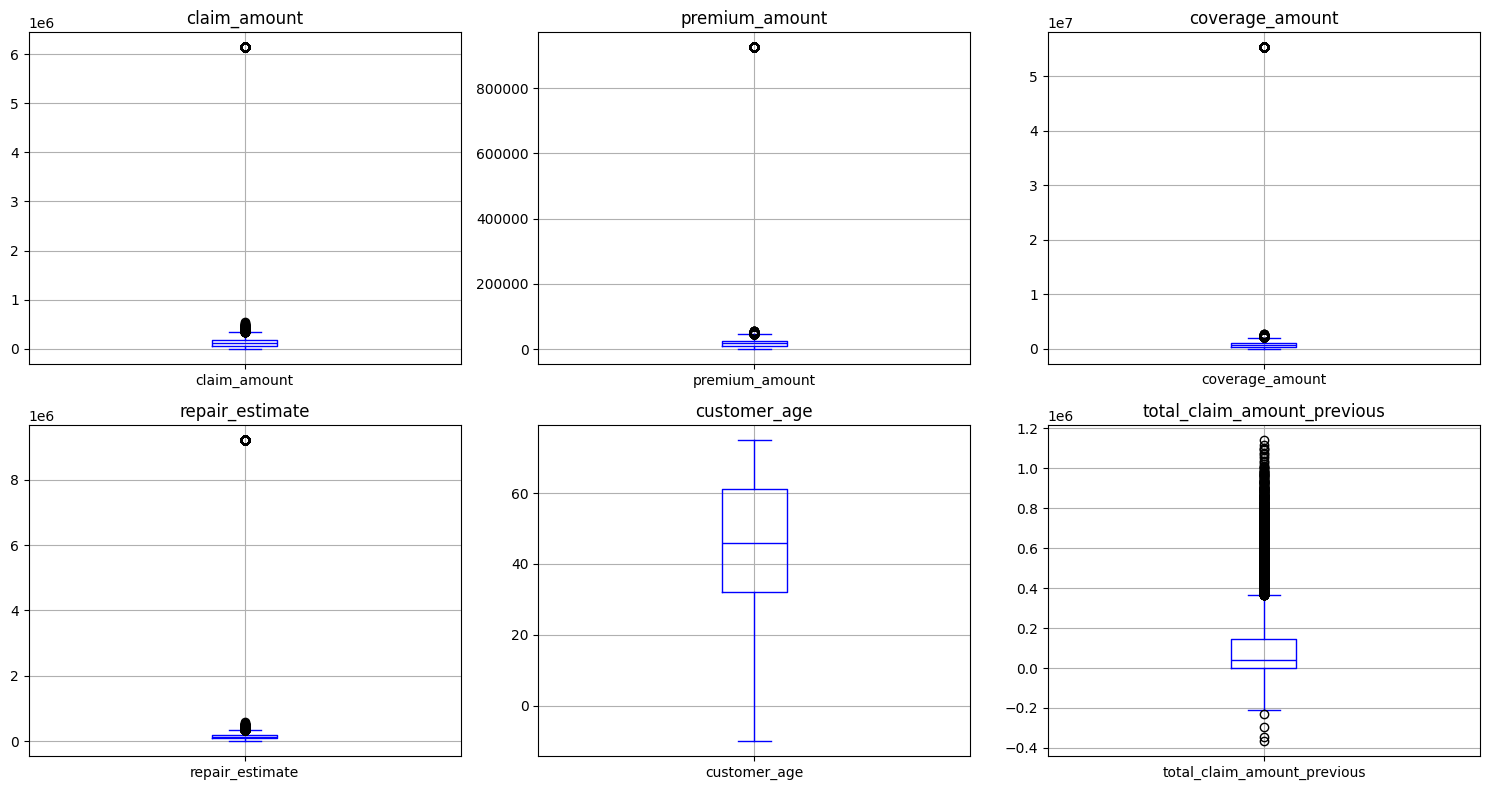

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

outlier_cols = ['claim_amount', 'premium_amount', 'coverage_amount',
                'repair_estimate', 'customer_age', 'total_claim_amount_previous']

for i, col in enumerate(outlier_cols):
    row, col_idx = i // 3, i % 3
    df_clean.boxplot(column=col, ax=axes[row, col_idx],color='blue')
    axes[row, col_idx].set_title(f'{col}')

plt.tight_layout()
plt.show()

\Outlier Treatment


In [81]:
#Outlier treatment using IQR method

def cap_outliers_iqr(df, col, factor=1.5):
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - factor * IQR
    upper = Q3 + factor * IQR
    
    # Count outliers
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    
    # Cap
    df[col] = df[col].clip(lower=lower, upper=upper)
    
    return outliers, lower, upper

# Apply to skewed numeric columns
outlier_cols = ['claim_amount', 'premium_amount', 'coverage_amount',
                'repair_estimate', 'total_claim_amount_previous']

for col in outlier_cols:
    n_outliers, low, high = cap_outliers_iqr(df_clean, col)
    print(f"{col}: capped {n_outliers} outliers [{low:.0f}, {high:.0f}]")

claim_amount: capped 723 outliers [-108322, 350224]
premium_amount: capped 644 outliers [-9028, 45416]
coverage_amount: capped 652 outliers [-670938, 2080709]
repair_estimate: capped 908 outliers [-78018, 343826]
total_claim_amount_previous: capped 3335 outliers [-220461, 367436]
